# Chapter 6: Lab: Linear Models and Regularization Methods

In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
from statsmodels.api import OLS
import sklearn.model_selection as skm
import sklearn.linear_model as skl
from sklearn.preprocessing import StandardScaler
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from functools import partial

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from ISLP.models import \
     (Stepwise,
      sklearn_selected,
      sklearn_selection_path)
import warnings
warnings.filterwarnings('ignore')

# Compatibility patch: l0bnb uses np.Inf, removed in NumPy >= 2.0
np.Inf = np.inf

from l0bnb import fit_path

## 6.5.1 Subset Selection Methods

### Forward Selection

We wish to predict a baseball player's `Salary` on the basis of various statistics associated with performance in the previous year.

**In [3]:**

In [3]:
Hitters = load_data('Hitters')
np.isnan(Hitters['Salary']).sum()

np.int64(59)

We see that `Salary` is missing for 59 players. The `dropna()` method of data frames removes all of the rows that have missing values in any variable.

**In [4]:**

In [4]:
Hitters = Hitters.dropna()
Hitters.shape

(263, 20)

We first choose the best model using forward selection based on $C_p$ (6.2). This score is not built in as a metric to `sklearn`. We therefore define a function to compute it ourselves, and use it as a scorer. By default, `sklearn` tries to maximize a score, hence our scoring function computes the negative $C_p$ statistic.

**In [5]:**

In [5]:
def nCp(sigma2, estimator, X, Y):
    "Negative Cp statistic"
    n, p = X.shape
    Yhat = estimator.predict(X)
    RSS = np.sum((Y - Yhat)**2)
    return -(RSS + 2 * p * sigma2) / n

We need to estimate the residual variance $\sigma^2$, which is the first argument in our scoring function above. We will fit the biggest model, using all the variables, and estimate $\sigma^2$ based on its MSE.

**In [6]:**

In [6]:
design = MS(Hitters.columns.drop('Salary')).fit(Hitters)
Y = np.array(Hitters['Salary'])
X = design.transform(Hitters)
sigma2 = OLS(Y,X).fit().scale

The function `sklearn_selected()` expects a scorer with just three arguments — the last three in the definition of `nCp()` above. We use the function `partial()` to freeze the first argument with our estimate of $\sigma^2$.

**In [7]:**

In [7]:
neg_Cp = partial(nCp, sigma2)

Along with a score we need to specify the search strategy. This is done through the object `Stepwise()` in the `ISLP.models` package. The method `Stepwise.first_peak()` runs forward stepwise until any further additions to the model do not result in an improvement in the evaluation score.

**In [8]:**

In [8]:
strategy = Stepwise.first_peak(design,
                                direction='forward',
                                max_terms=len(design.terms))

We now fit a linear regression model with `Salary` as outcome using forward selection. Without specifying a scoring argument, the score defaults to MSE, and so all 19 variables will be selected.

**In [9]:**

In [9]:
hitters_MSE = sklearn_selected(OLS,
                                strategy)
hitters_MSE.fit(Hitters, Y)
hitters_MSE.selected_state_

('Assists',
 'AtBat',
 'CAtBat',
 'CHits',
 'CHmRun',
 'CRBI',
 'CRuns',
 'CWalks',
 'Division',
 'Errors',
 'Hits',
 'HmRun',
 'League',
 'NewLeague',
 'PutOuts',
 'RBI',
 'Runs',
 'Walks',
 'Years')

Using `neg_Cp` results in a smaller model, as expected, with just 10 variables selected.

**In [10]:**

In [10]:
hitters_Cp = sklearn_selected(OLS,
                              strategy,
                              scoring=neg_Cp)
hitters_Cp.fit(Hitters, Y)
hitters_Cp.selected_state_

('Assists',
 'AtBat',
 'CAtBat',
 'CRBI',
 'CRuns',
 'CWalks',
 'Division',
 'Hits',
 'PutOuts',
 'Walks')

### Choosing Among Models Using the Validation Set Approach and Cross-Validation

As an alternative to using $C_p$, we might try cross-validation to select a model in forward selection. For this, we need a method that stores the full path of models found in forward selection, and allows predictions for each of these. This can be done with the `sklearn_selection_path()` estimator from `ISLP.models`.

**In [11]:**

In [11]:
strategy = Stepwise.fixed_steps(design,
                                 len(design.terms),
                                 direction='forward')
full_path = sklearn_selection_path(OLS, strategy)

We now fit the full forward-selection path on the `Hitters` data and compute the fitted values.

**In [12]:**

In [12]:
full_path.fit(Hitters, Y)
Yhat_in = full_path.predict(Hitters)
Yhat_in.shape

(263, 20)

This gives us an array of fitted values — 20 steps in all, including the fitted mean for the null model — which we can use to evaluate in-sample MSE. As expected, the in-sample MSE improves each step we take.

**In [13]:**

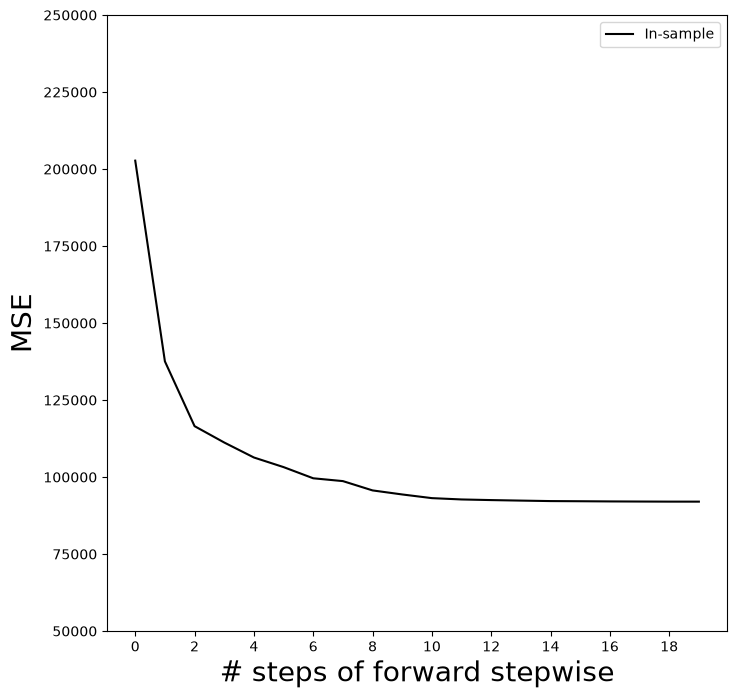

In [13]:
mse_fig, ax = subplots(figsize=(8,8))
insample_mse = ((Yhat_in - Y[:,None])**2).mean(0)
n_steps = insample_mse.shape[0]
ax.plot(np.arange(n_steps),
        insample_mse,
        'k', # color black
        label='In-sample')
ax.set_ylabel('MSE',
               fontsize=20)
ax.set_xlabel('# steps of forward stepwise',
               fontsize=20)
ax.set_xticks(np.arange(n_steps)[::2])
ax.legend()
ax.set_ylim([50000,250000]);

We are now ready to use cross-validation to estimate test error along the model path. We compute the cross-validated predicted values using 5-fold cross-validation.

**In [14]:**

In [14]:
K=5
kfold = skm.KFold(K,
                   random_state=0,
                   shuffle=True)
Yhat_cv = skm.cross_val_predict(full_path,
                                 Hitters,
                                 Y,
                                 cv=kfold)
Yhat_cv.shape

(263, 20)

At each model along the path, we compute the MSE in each of the cross-validation folds.

**In [15]:**

In [15]:
cv_mse = []
for train_idx, test_idx in kfold.split(Y):
    errors = (Yhat_cv[test_idx] - Y[test_idx,None])**2
    cv_mse.append(errors.mean(0)) # column means
cv_mse = np.array(cv_mse).T
cv_mse.shape

(20, 5)

We now add the cross-validation error estimates to our MSE plot, including the mean error across the five folds and the estimate of the standard error of the mean.

**In [16]:**

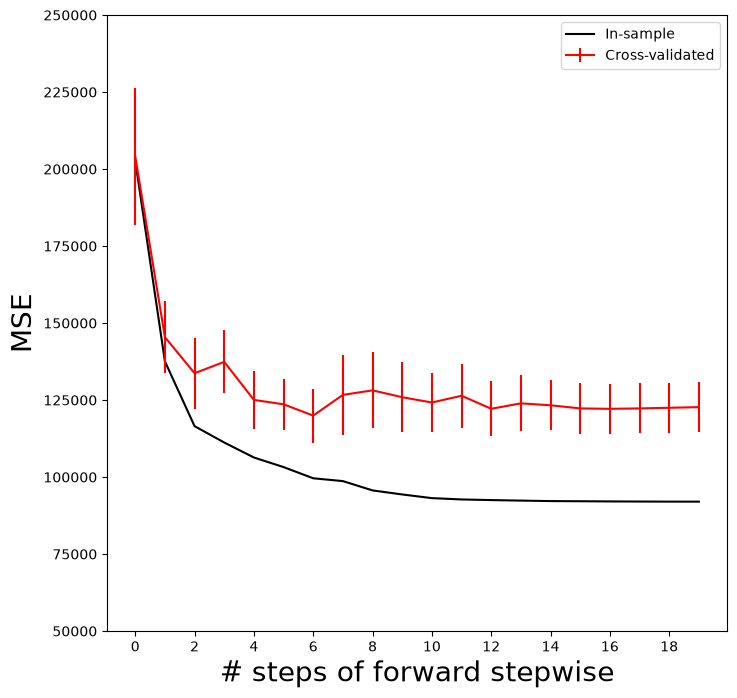

In [16]:
ax.errorbar(np.arange(n_steps),
            cv_mse.mean(1),
            cv_mse.std(1) / np.sqrt(K),
            label='Cross-validated',
            c='r') # color red
ax.set_ylim([50000,250000])
ax.legend()
mse_fig

To repeat the above using the validation set approach, we simply change our `cv` argument to a validation set: one random split of the data into a test and training set, with a test size of 20%.

**In [17]:**

In [17]:
validation = skm.ShuffleSplit(n_splits=1,
                               test_size=0.2,
                               random_state=0)
for train_idx, test_idx in validation.split(Y):
    full_path.fit(Hitters.iloc[train_idx],
                  Y[train_idx])
    Yhat_val = full_path.predict(Hitters.iloc[test_idx])
    errors = (Yhat_val - Y[test_idx,None])**2
    validation_mse = errors.mean(0)

**In [18]:**

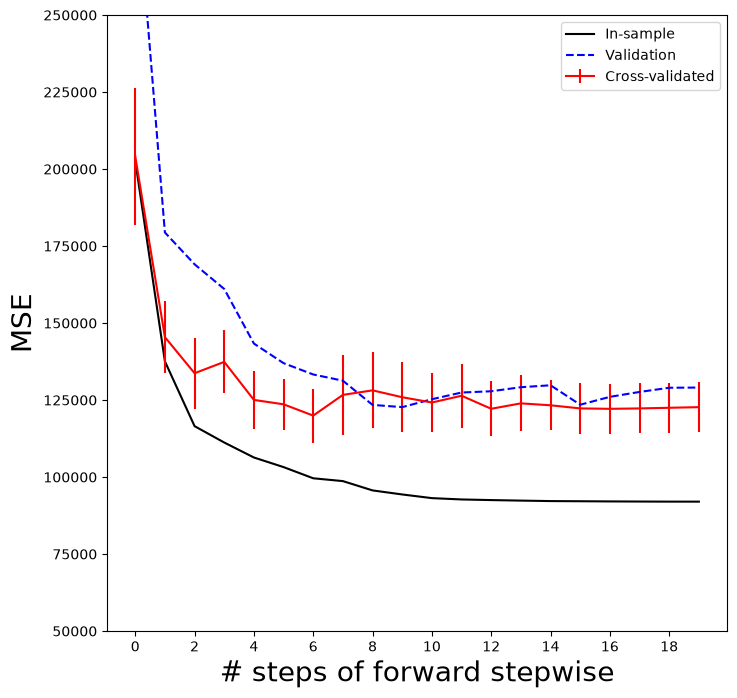

In [18]:
ax.plot(np.arange(n_steps),
        validation_mse,
        'b--', # color blue, broken line
        label='Validation')
ax.set_xticks(np.arange(n_steps)[::2])
ax.set_ylim([50000,250000])
ax.legend()
mse_fig

### Best Subset Selection

Forward stepwise is a greedy selection procedure; at each step it augments the current set by including one additional variable. We now apply best subset selection to the `Hitters` data, which for every subset size, searches for the best set of predictors, using the `l0bnb` package.

**In [19]:**

In [19]:
D = design.fit_transform(Hitters)
D = D.drop('intercept', axis=1)
X = np.asarray(D)

Here we excluded the first column corresponding to the intercept, as `l0bnb` will fit the intercept separately. We can find a path using the `fit_path()` function.

**In [20]:**

In [20]:
path = fit_path(X,
                 Y,
                 max_nonzeros=X.shape[1])

Preprocessing Data.
BnB Started.
Iteration: 1. Number of non-zeros:  1
Iteration: 2. Number of non-zeros:  2
Iteration: 3. Number of non-zeros:  2
Iteration: 4. Number of non-zeros:  2
Iteration: 5. Number of non-zeros:  3
Iteration: 6. Number of non-zeros:  3
Iteration: 7. Number of non-zeros:  4
Iteration: 8. Number of non-zeros:  9
Iteration: 9. Number of non-zeros:  9
Iteration: 10. Number of non-zeros:  9
Iteration: 11. Number of non-zeros:  9
Iteration: 12. Number of non-zeros:  9
Iteration: 13. Number of non-zeros:  9
Iteration: 14. Number of non-zeros:  9
Iteration: 15. Number of non-zeros:  9
Iteration: 16. Number of non-zeros:  9
Iteration: 17. Number of non-zeros:  9
Iteration: 18. Number of non-zeros:  17
Iteration: 19. Number of non-zeros:  19


Iteration: 6. Number of non-zeros:  3


Iteration: 7. Number of non-zeros:  4


Iteration: 8. Number of non-zeros:  9
Iteration: 9. Number of non-zeros:  9
Iteration: 10. Number of non-zeros:  9
Iteration: 11. Number of non-zeros:  9
Iteration: 12. Number of non-zeros:  9
Iteration: 13. Number of non-zeros:  9
Iteration: 14. Number of non-zeros:  9
Iteration: 15. Number of non-zeros:  9
Iteration: 16. Number of non-zeros:  9
Iteration: 17. Number of non-zeros:  9
Iteration: 18. Number of non-zeros:  17
Iteration: 19. Number of non-zeros:  19


The function `fit_path()` returns a list whose values include the fitted coefficients as `B`, an intercept as `B0`, as well as a few other attributes related to the particular path algorithm used.

**In [21]:**

In [21]:
path[3]

{'B': array([0.        , 3.25484367, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.67775265, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ]),
 'B0': np.float64(-38.98216739555505),
 'lambda_0': np.float64(0.011416248027450187),
 'M': np.float64(0.5829861733382012),
 'Time_exceeded': False}

In the example above, we see that at the fourth step in the path, we have two nonzero coefficients in `'B'`, corresponding to the value 0.114 for the penalty parameter `lambda_0`. We could make predictions using this sequence of fits on a validation set as a function of `lambda_0`, or with more work using cross-validation.

## 6.5.2 Ridge Regression and the Lasso

We will use the `sklearn.linear_model` package (`skl`) to fit ridge and lasso regularized linear models on the `Hitters` data. We start with the model matrix `X` (without an intercept) that we computed in the previous section on best subset regression.

### Ridge Regression

We will use the function `skl.ElasticNet()` to fit both ridge and the lasso. To fit a path of ridge regression models, we use `skl.ElasticNet.path()`, which can fit both ridge and lasso, as well as a hybrid mixture; ridge regression corresponds to `l1_ratio=0`.

**In [22]:**

In [22]:
Xs = X - X.mean(0)[None,:]
X_scale = X.std(0)
Xs = Xs / X_scale[None,:]
lambdas = 10**np.linspace(8, -2, 100) / Y.std()
soln_array = skl.ElasticNet.path(Xs,
                                  Y,
                                  l1_ratio=0.,
                                  alphas=lambdas)[1]
soln_array.shape

(19, 100)

Here we extract the array of coefficients corresponding to the solutions along the regularization path. We transpose this matrix and turn it into a data frame to facilitate viewing and plotting.

**In [23]:**

In [23]:
soln_path = pd.DataFrame(soln_array.T,
                          columns=D.columns,
                          index=-np.log(lambdas))
soln_path.index.name = 'negative log(lambda)'
soln_path

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League[N],Division[W],PutOuts,Assists,Errors,NewLeague[N]
negative log(lambda),,,,,,,,,,,,,,,,,,,
-12.310855,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
-12.078271,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
-11.845686,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
-11.613102,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
-11.380518,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9.784658,-289.996568,334.900335,36.473153,-58.501790,-25.719708,134.573060,-16.888219,-396.132234,107.742403,-7.075781,468.492732,248.849471,-211.631278,31.412861,-58.462157,78.751831,53.842150,-22.342587,-12.586958
10.017243,-290.029450,335.162913,36.658484,-58.750152,-25.897874,134.620003,-16.741406,-396.772560,106.230133,-7.887377,470.000000,250.268837,-211.834906,31.403306,-58.451212,78.748866,53.859095,-22.325593,-12.563830
10.249827,-290.067133,335.397862,36.815896,-58.963198,-26.048751,134.661168,-16.630426,-397.162849,104.792702,-8.595946,471.291473,251.498935,-212.016626,31.393726,-58.442527,78.746696,53.869499,-22.310387,-12.543160


We plot the paths to get a sense of how the coefficients vary with $\lambda$.

**In [24]:**

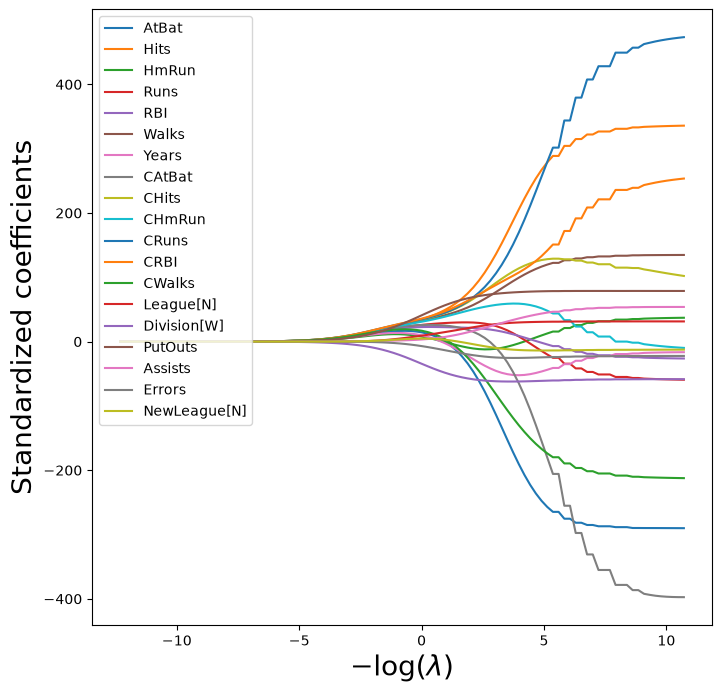

In [24]:
path_fig, ax = subplots(figsize=(8,8))
soln_path.plot(ax=ax, legend=False)
ax.set_xlabel('$-\\log(\\lambda)$', fontsize=20)
ax.set_ylabel('Standardized coefficients', fontsize=20)
ax.legend(loc='upper left');

We expect the coefficient estimates to be much smaller, in terms of $\ell_2$ norm, when a large value of $\lambda$ is used, as compared to when a small value of $\lambda$ is used. We display the coefficients at the 40th step, where $\lambda$ is 25.535.

**In [25]:**

In [25]:
beta_hat = soln_path.loc[soln_path.index[39]]
lambdas[39], beta_hat

(np.float64(25.53538897200662),
 AtBat           5.433750
 Hits            6.223581
 HmRun           4.585497
 Runs            5.880855
 RBI             6.195921
 Walks           6.277974
 Years           5.299766
 CAtBat          7.147501
 CHits           7.539495
 CHmRun          7.182344
 CRuns           7.728649
 CRBI            7.790702
 CWalks          6.592901
 League[N]       0.042445
 Division[W]    -3.107159
 PutOuts         4.605263
 Assists         0.378371
 Errors         -0.135196
 NewLeague[N]    0.150323
 Name: -3.240065292879872, dtype: float64)

Let's compute the $\ell_2$ norm of the standardized coefficients.

**In [26]:**

In [26]:
np.linalg.norm(beta_hat)

np.float64(24.170616077668743)

In contrast, here is the $\ell_2$ norm when $\lambda$ is 2.44e-01. Note the much larger $\ell_2$ norm of the coefficients associated with this smaller value of $\lambda$.

**In [27]:**

In [27]:
beta_hat = soln_path.loc[soln_path.index[59]]
lambdas[59], np.linalg.norm(beta_hat)

(np.float64(0.24374766133488554), np.float64(160.4361421400731))

Above we normalized `X` upfront, and fit the ridge model using `Xs`. The `Pipeline()` object in `sklearn` provides a clear way to separate feature normalization from the fitting of the ridge model itself.

**In [28]:**

In [28]:
ridge = skl.ElasticNet(alpha=lambdas[59], l1_ratio=0)
scaler = StandardScaler(with_mean=True, with_std=True)
pipe = Pipeline(steps=[('scaler', scaler), ('ridge', ridge)])
pipe.fit(X, Y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](19,)","[403.64,107.83, 11.62,...,118.76, 8.59, 0.46]"


We show that it gives the same $\ell_2$ norm as in our previous fit on the standardized data.

**In [29]:**

In [29]:
np.linalg.norm(ridge.coef_)

np.float64(160.4166112808915)

### Estimating Test Error of Ridge Regression

Choosing an a priori value of $\lambda$ for ridge regression is difficult if not impossible. We will want to use the validation method or cross-validation to select the tuning parameter.

**In [30]:**

In [30]:
validation = skm.ShuffleSplit(n_splits=1,
                               test_size=0.5,
                               random_state=0)
ridge.alpha = 0.01
results = skm.cross_validate(ridge,
                              X,
                              Y,
                              scoring='neg_mean_squared_error',
                              cv=validation)
-results['test_score']

array([134214.00419204])

Note that if we had instead simply fit a model with just an intercept, we would have predicted each test observation using the mean of the training observations. We can get the same result by fitting a ridge regression model with a very large value of $\lambda$.

**In [31]:**

In [31]:
ridge.alpha = 1e10
results = skm.cross_validate(ridge,
                              X,
                              Y,
                              scoring='neg_mean_squared_error',
                              cv=validation)
-results['test_score']

array([231853.41506334])

Obviously choosing $\lambda=0.01$ is arbitrary, so we will use cross-validation or the validation-set approach to choose the tuning parameter $\lambda$. `GridSearchCV()` allows exhaustive grid search to choose such a parameter. We first use the validation set method to choose $\lambda$.

**In [32]:**

In [32]:
param_grid = {'ridge__alpha': lambdas}
grid = skm.GridSearchCV(pipe,
                         param_grid,
                         cv=validation,
                         scoring='neg_mean_squared_error')
grid.fit(X, Y)
grid.best_params_['ridge__alpha']
grid.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](19,)","[403.64,107.83, 11.62,...,118.76, 8.59, 0.46]"


Alternatively, we can use 5-fold cross-validation.

**In [33]:**

In [33]:
grid = skm.GridSearchCV(pipe,
                         param_grid,
                         cv=kfold,
                         scoring='neg_mean_squared_error')
grid.fit(X, Y)
grid.best_params_['ridge__alpha']
grid.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](19,)","[403.64,107.83, 11.62,...,118.76, 8.59, 0.46]"


We now plot the cross-validated MSE as a function of $-\log(\lambda)$, which has shrinkage decreasing from left to right.

**In [34]:**

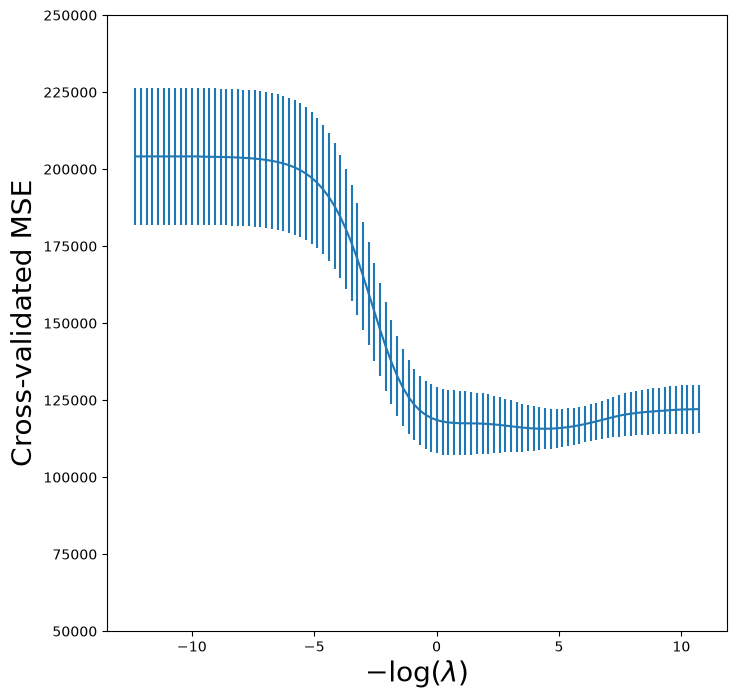

In [34]:
ridge_fig, ax = subplots(figsize=(8,8))
ax.errorbar(-np.log(lambdas),
            -grid.cv_results_['mean_test_score'],
            yerr=grid.cv_results_['std_test_score'] / np.sqrt(K))
ax.set_ylim([50000,250000])
ax.set_xlabel('$-\\log(\\lambda)$', fontsize=20)
ax.set_ylabel('Cross-validated MSE', fontsize=20);

One can cross-validate different metrics to choose a parameter. The default metric for `skl.ElasticNet()` is test $R^2$. Let's compare $R^2$ to MSE for cross-validation here.

**In [35]:**

In [35]:
grid_r2 = skm.GridSearchCV(pipe,
                            param_grid,
                            cv=kfold)
grid_r2.fit(X, Y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...l1_ratio=0))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'ridge__alpha': array([2.2209...22093791e-05])}
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosit

Finally, let's plot the results for cross-validated $R^2$.

**In [36]:**

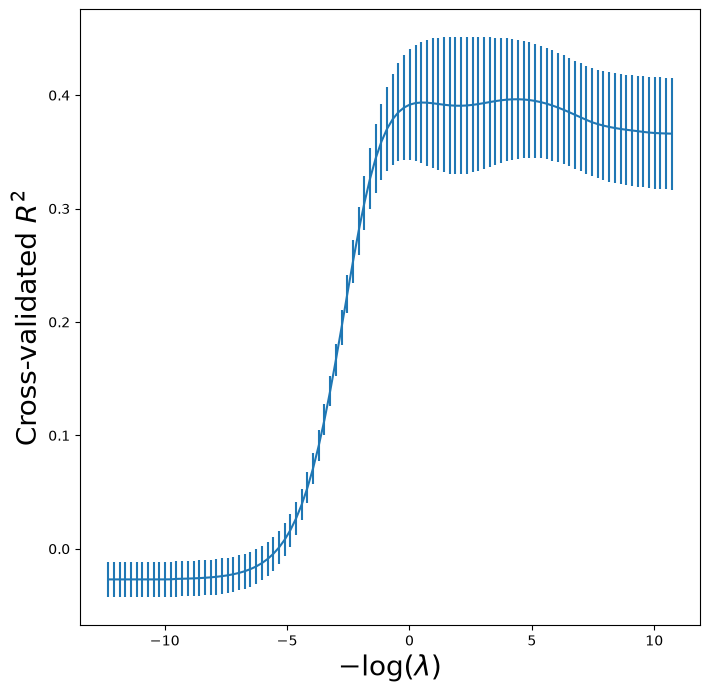

In [36]:
r2_fig, ax = subplots(figsize=(8,8))
ax.errorbar(-np.log(lambdas),
            grid_r2.cv_results_['mean_test_score'],
            yerr=grid_r2.cv_results_['std_test_score'] / np.sqrt(K)
            )
ax.set_xlabel('$-\\log(\\lambda)$', fontsize=20)
ax.set_ylabel('Cross-validated $R^2$', fontsize=20);

### Fast Cross-Validation for Solution Paths

The ridge, lasso, and elastic net can be efficiently fit along a sequence of $\lambda$ values, creating a solution path (or regularization path). Hence there is specialized code to fit such paths, and to choose a suitable value of $\lambda$ using cross-validation.

**In [37]:**

In [37]:
ridgeCV = skl.ElasticNetCV(alphas=lambdas,
                            l1_ratio=0,
                            cv=kfold)
pipeCV = Pipeline(steps=[('scaler', scaler),
                          ('ridge', ridgeCV)])
pipeCV.fit(X, Y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value
"mean_ mean_: ndarray of shape (n_features,) or NoneThe mean value for each feature in the training set.Equal to ``None`` when ``with_mean=False`` and ``with_std=False``.","ndarray[float64](19,)","[403.64,107.83, 11.62,...,118.76, 8.59, 0.46]"


Let's produce a plot again of the cross-validation error to see that it is similar to using `skm.GridSearchCV`.

**In [38]:**

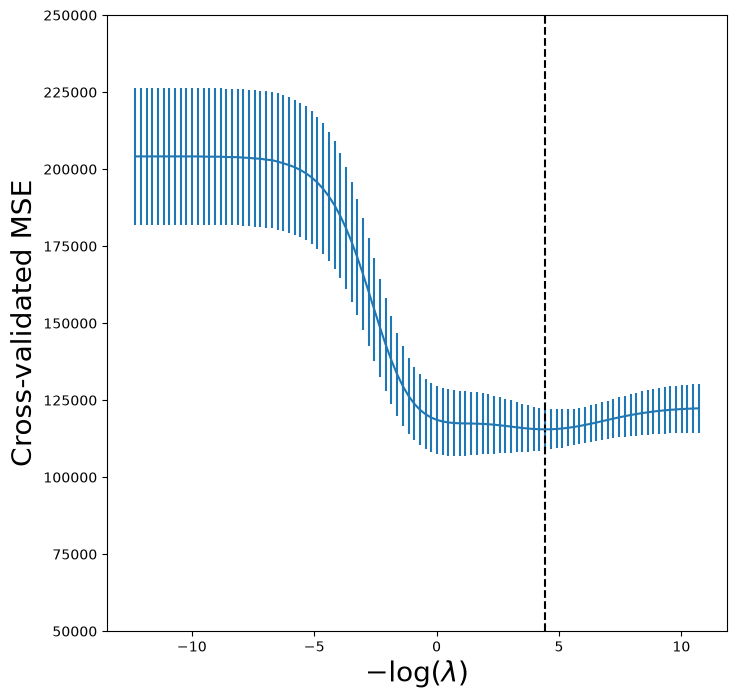

In [38]:
tuned_ridge = pipeCV.named_steps['ridge']
ridgeCV_fig, ax = subplots(figsize=(8,8))
ax.errorbar(-np.log(lambdas),
            tuned_ridge.mse_path_.mean(1),
            yerr=tuned_ridge.mse_path_.std(1) / np.sqrt(K))
ax.axvline(-np.log(tuned_ridge.alpha_), c='k', ls='--')
ax.set_ylim([50000,250000])
ax.set_xlabel('$-\\log(\\lambda)$', fontsize=20)
ax.set_ylabel('Cross-validated MSE', fontsize=20);

We see that the value of $\lambda$ that results in the smallest cross-validation error is available as the value `tuned_ridge.alpha_`. What is the test MSE associated with this value of $\lambda$?

**In [39]:**

In [39]:
np.min(tuned_ridge.mse_path_.mean(1))

np.float64(115519.65106973382)

Finally, `tuned_ridge.coef_` has the coefficients fit on the entire data set at this value of $\lambda$.

**In [40]:**

In [40]:
tuned_ridge.coef_

array([-222.89879608,  238.75984009,    3.19940859,   -2.78622901,
          3.65641889,  108.90696355,  -50.99835353, -103.8607335 ,
        121.8831849 ,   57.24126481,  209.34371641,  117.88285202,
       -150.10311712,   30.35774054,  -61.64169747,   77.73148598,
         40.04131722,  -25.02859526,  -13.69424589])

As expected, none of the coefficients are zero — ridge regression does not perform variable selection!

### Evaluating Test Error of Cross-Validated Ridge

Choosing $\lambda$ using cross-validation provides a single regression estimator. It is therefore reasonable to estimate what its test error is. We run into a problem here in that cross-validation will have touched all of its data in choosing $\lambda$, hence we have no further data to estimate test error. A compromise is to do an initial split of the data into two disjoint sets: a training set and a test set. We then fit a cross-validation tuned ridge regression on the training set, and evaluate its performance on the test set. Below, we use 75% for training and 25% for test, with the estimator being ridge regression tuned using 5-fold cross-validation.

**In [41]:**

In [41]:
outer_valid = skm.ShuffleSplit(n_splits=1,
                                test_size=0.25,
                                random_state=1)
inner_cv = skm.KFold(n_splits=5,
                      shuffle=True,
                      random_state=2)
ridgeCV = skl.ElasticNetCV(alphas=lambdas,
                            l1_ratio=0,
                            cv=inner_cv)
pipeCV = Pipeline(steps=[('scaler', scaler),
                          ('ridge', ridgeCV)]);

**In [42]:**

In [42]:
results = skm.cross_validate(pipeCV,
                              X,
                              Y,
                              cv=outer_valid,
                              scoring='neg_mean_squared_error')
-results['test_score']

array([132393.96280408])

### The Lasso

We saw that ridge regression with a wise choice of $\lambda$ can outperform least squares as well as the null model on the `Hitters` data set. We now ask whether the lasso can yield either a more accurate or a more interpretable model than ridge regression. We use `ElasticNetCV()` again, this time with the argument `l1_ratio=1`.

**In [43]:**

In [43]:
lassoCV = skl.ElasticNetCV(l1_ratio=1,
                            cv=kfold)
pipeCV = Pipeline(steps=[('scaler', scaler),
                          ('lasso', lassoCV)])
pipeCV.fit(X, Y)
tuned_lasso = pipeCV.named_steps['lasso']
tuned_lasso.alpha_

np.float64(3.1472370031649866)

**In [44]:**

In [44]:
lambdas, soln_array = skl.Lasso.path(Xs,
                                      Y,
                                      l1_ratio=1,
                                      n_alphas=100)[:2]
soln_path = pd.DataFrame(soln_array.T,
                          columns=D.columns,
                          index=-np.log(lambdas))

We can see from the coefficient plot of the standardized coefficients that depending on the choice of tuning parameter, some of the coefficients will be exactly equal to zero.

**In [45]:**

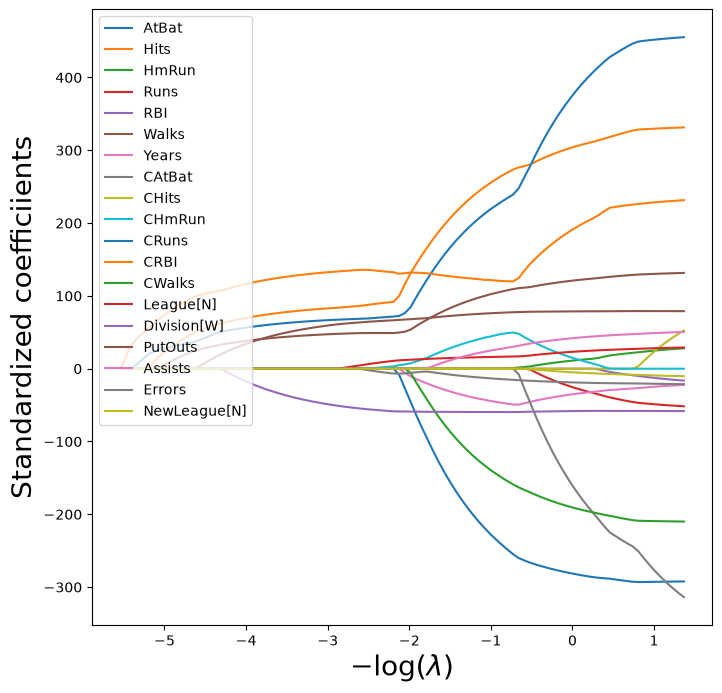

In [45]:
path_fig, ax = subplots(figsize=(8,8))
soln_path.plot(ax=ax, legend=False)
ax.legend(loc='upper left')
ax.set_xlabel('$-\\log(\\lambda)$', fontsize=20)
ax.set_ylabel('Standardized coefficiients', fontsize=20);

The smallest cross-validated error is lower than the test set MSE of the null model and of least squares, and very similar to the test MSE of ridge regression with $\lambda$ chosen by cross-validation.

**In [46]:**

In [46]:
np.min(tuned_lasso.mse_path_.mean(1))

np.float64(114690.73118253537)

Let's again produce a plot of the cross-validation error.

**In [47]:**

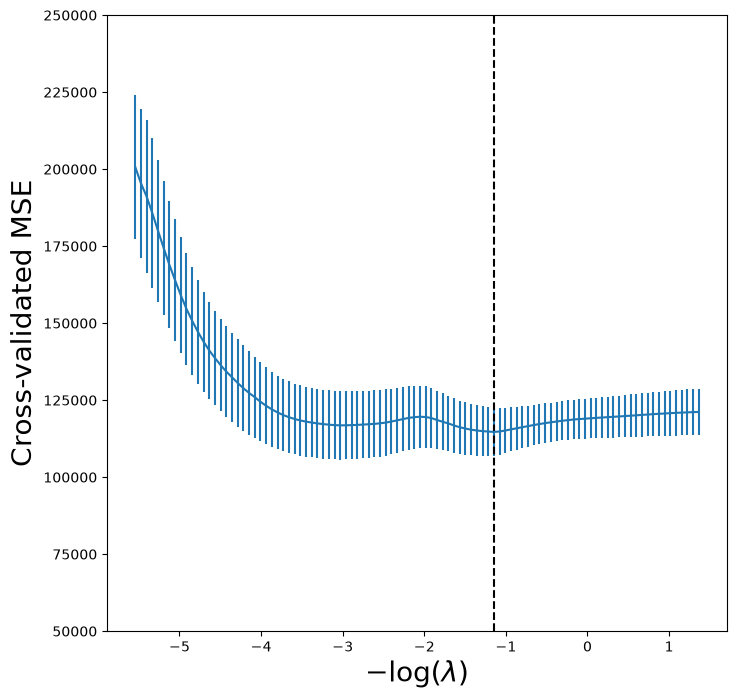

In [47]:
lassoCV_fig, ax = subplots(figsize=(8,8))
ax.errorbar(-np.log(tuned_lasso.alphas_),
            tuned_lasso.mse_path_.mean(1),
            yerr=tuned_lasso.mse_path_.std(1) / np.sqrt(K))
ax.axvline(-np.log(tuned_lasso.alpha_), c='k', ls='--')
ax.set_ylim([50000,250000])
ax.set_xlabel('$-\\log(\\lambda)$', fontsize=20)
ax.set_ylabel('Cross-validated MSE', fontsize=20);

However, the lasso has a substantial advantage over ridge regression in that the resulting coefficient estimates are sparse. Here we see that several coefficient estimates are exactly zero.

**In [48]:**

In [48]:
tuned_lasso.coef_

array([-210.01008773,  243.4550306 ,    0.        ,    0.        ,
          0.        ,   97.69397357,  -41.52283116,   -0.        ,
          0.        ,   39.62298193,  205.75273856,  124.55456561,
       -126.29986768,   15.70262427,  -59.50157967,   75.24590036,
         21.62698014,  -12.04423675,   -0.        ])

## 6.5.3 PCR and PLS Regression

### Principal Components Regression

Principal components regression (PCR) can be performed using `PCA()` from the `sklearn.decomposition` module. We now apply PCR to the `Hitters` data, in order to predict `Salary`. We use `LinearRegression()` to fit the regression model here.

**In [49]:**

In [49]:
pca = PCA(n_components=2)
linreg = skl.LinearRegression()
pipe = Pipeline([('pca', pca),
                  ('linreg', linreg)])
pipe.fit(X, Y)
pipe.named_steps['linreg'].coef_

array([0.09846131, 0.4758765 ])

When performing PCA, the results vary depending on whether the data has been standardized or not. This can be accomplished by including an additional step in the pipeline.

**In [50]:**

In [50]:
pipe = Pipeline([('scaler', scaler),
                  ('pca', pca),
                  ('linreg', linreg)])
pipe.fit(X, Y)
pipe.named_steps['linreg'].coef_

array([106.36859204,  21.60350456])

We can of course use CV to choose the number of components, using `skm.GridSearchCV`, in this case fixing the parameters to vary the `n_components`.

**In [51]:**

In [51]:
param_grid = {'pca__n_components': range(1, 20)}
grid = skm.GridSearchCV(pipe,
                         param_grid,
                         cv=kfold,
                         scoring='neg_mean_squared_error')
grid.fit(X, Y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'pca__n_components': range(1, 20)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the

Let's plot the results as we have for other methods.

**In [52]:**

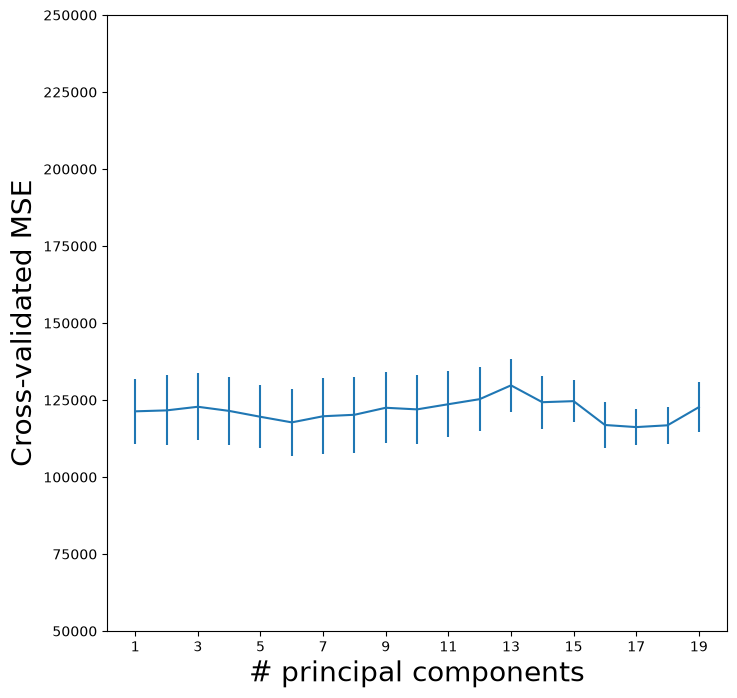

In [52]:
pcr_fig, ax = subplots(figsize=(8,8))
n_comp = param_grid['pca__n_components']
ax.errorbar(n_comp,
            -grid.cv_results_['mean_test_score'],
            grid.cv_results_['std_test_score'] / np.sqrt(K))
ax.set_ylabel('Cross-validated MSE', fontsize=20)
ax.set_xlabel('# principal components', fontsize=20)
ax.set_xticks(n_comp[::2])
ax.set_ylim([50000,250000]);

We see that the smallest cross-validation error occurs when 17 components are used. However, from the plot we also see that the cross-validation error is roughly the same when only one component is included in the model. The CV score is provided for each possible number of components from 1 to 19 inclusive. The `PCA()` method complains if we try to fit an intercept only with `n_components=0` so we also compute the MSE for just the null model with these splits.

**In [53]:**

In [53]:
Xn = np.zeros((X.shape[0], 1))
cv_null = skm.cross_validate(linreg,
                              Xn,
                              Y,
                              cv=kfold,
                              scoring='neg_mean_squared_error')
-cv_null['test_score'].mean()

np.float64(204139.30692994667)

The `explained_variance_ratio_` attribute of our PCA object provides the percentage of variance explained in the predictors using different numbers of components.

**In [54]:**

In [54]:
pipe.named_steps['pca'].explained_variance_ratio_

array([0.3831424 , 0.21841076])

### Partial Least Squares

Partial least squares (PLS) is implemented in the `PLSRegression()` function.

**In [55]:**

In [55]:
pls = PLSRegression(n_components=2,
                     scale=True)
pls.fit(X, Y)

,"n_components n_components: int, default=2Number of components to keep. Should be in `[1, n_features]`.",2
,"scale scale: bool, default=TrueWhether to scale `X` and `y`.",True
,"max_iter max_iter: int, default=500The maximum number of iterations of the power method when`algorithm='nipals'`. Ignored otherwise.",500
,"tol tol: float, default=1e-06The tolerance used as convergence criteria in the power method: thealgorithm stops whenever the squared norm of `u_i - u_{i-1}` is lessthan `tol`, where `u` corresponds to the left singular vector.",1e-06
,"copy copy: bool, default=TrueWhether to copy `X` and `y` in :term:`fit` before applying centering,and potentially scaling. If `False`, these operations will be doneinplace, modifying both arrays.",True
Name,Type,Value
"coef_ coef_: ndarray of shape (n_target, n_features)The coefficients of the linear model such that `y` is approximated as`y = X @ coef_.T + intercept_`.","ndarray[float64](1, 19)","[[ 0.18, 0.97, 1.43,..., 0.03,-0.66,30.21]]"
"intercept_ intercept_: ndarray of shape (n_targets,)The intercepts of the linear model such that `y` is approximated as`y = X @ coef_.T + intercept_`... versionadded:: 1.1","ndarray[float64](1,)",[535.93]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,19
"n_iter_ n_iter_: list of shape (n_components,)Number of iterations of the power method, for eachcomponent.",list,"[1, 1]"
"x_loadings_ x_loadings_: ndarray of shape (n_features, n_components)The loadings of `X`.","ndarray[float64](19, 2)","[[ 0.23, 0.35], [ 0.22, 0.36], [ 0.22, 0.09], ..., [ 0.01, 0.13], [ 0. , 0.16], [-0.03, 0.31]]"


As was the case in PCR, we will want to use CV to choose the number of components.

**In [56]:**

In [56]:
param_grid = {'n_components':range(1, 20)}
grid = skm.GridSearchCV(pls,
                         param_grid,
                         cv=kfold,
                         scoring='neg_mean_squared_error')
grid.fit(X, Y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",PLSRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_components': range(1, 20)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of inform

As for our other methods, we plot the MSE.

**In [57]:**

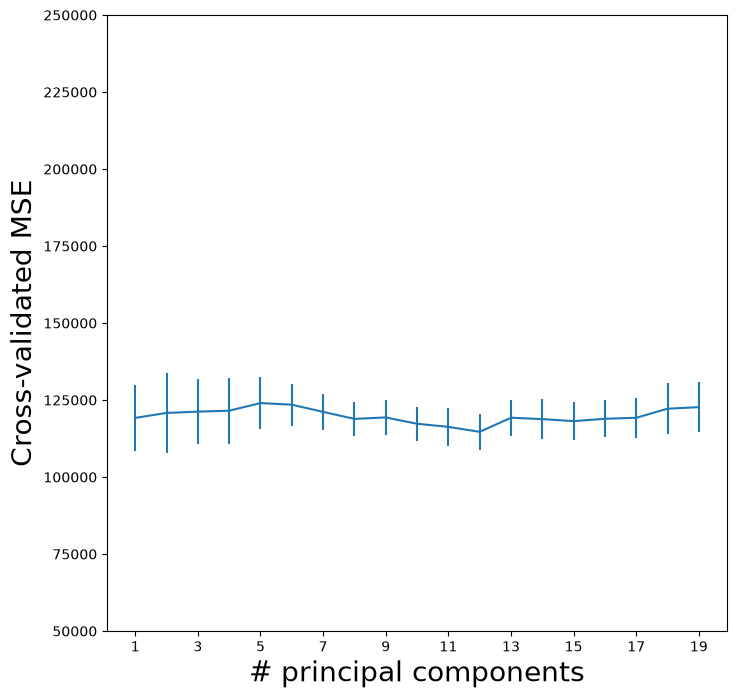

In [57]:
pls_fig, ax = subplots(figsize=(8,8))
n_comp = param_grid['n_components']
ax.errorbar(n_comp,
            -grid.cv_results_['mean_test_score'],
            grid.cv_results_['std_test_score'] / np.sqrt(K))
ax.set_ylabel('Cross-validated MSE', fontsize=20)
ax.set_xlabel('# principal components', fontsize=20)
ax.set_xticks(n_comp[::2])
ax.set_ylim([50000,250000]);

CV error is minimized at 12, though there is little noticeable difference between this point and a much lower number like 2 or 3 components.